# 📊 EDA avanzado – Dataset Brazilian E-commerce Olist
## Proyecto integrador: Ecommify | Diseño y Optimización de Bases de Datos

**Propósito:** análisis exploratorio orientado a decisiones de arquitectura, normalización, modelado físico y diseño híbrido **PostgreSQL + MongoDB**.

Este notebook convierte el EDA en insumo técnico para claves, relaciones, calidad de datos, índices, particionamiento, diseño documental NoSQL y artefactos exportables.


## 1. Configuración inicial

Ejecutar esta celda en Google Colab. Si los archivos están en otra carpeta, ajustar la variable `BASE_PATH`.


In [1]:
# Montaje opcional de Google Drive en Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('No se está ejecutando en Google Colab o Drive ya está montado:', e)


Mounted at /content/drive


In [2]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True


## 2. Carga de datos

El dataset Olist incluye 9 archivos principales. Esta celda carga todas las tablas necesarias para el análisis.


In [3]:
# Ajustar esta ruta según la ubicación real de los CSV en Google Drive
BASE_PATH = '/content/drive/MyDrive/diseno_bases_datos/Olist/'

files = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'payments': 'olist_order_payments_dataset.csv',
    'reviews': 'olist_order_reviews_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

data = {}
for name, filename in files.items():
    full_path = os.path.join(BASE_PATH, filename)
    data[name] = pd.read_csv(full_path)
    print(f'{name}: {data[name].shape[0]:,} filas x {data[name].shape[1]:,} columnas')

customers = data['customers']
geolocation = data['geolocation']
order_items = data['order_items']
payments = data['payments']
reviews = data['reviews']
orders = data['orders']
products = data['products']
sellers = data['sellers']
category_translation = data['category_translation']


customers: 99,441 filas x 5 columnas
geolocation: 1,000,163 filas x 5 columnas
order_items: 112,650 filas x 7 columnas
payments: 103,886 filas x 5 columnas
reviews: 99,224 filas x 7 columnas
orders: 99,441 filas x 8 columnas
products: 32,951 filas x 9 columnas
sellers: 3,095 filas x 4 columnas
category_translation: 71 filas x 2 columnas


## 3. Perfil general de tablas

Se resume volumen, columnas, duplicados y memoria usada por cada tabla. Esto ayuda a dimensionar el modelo físico y las posibles decisiones de particionamiento o indexación.


In [4]:
summary = []
for name, df in data.items():
    summary.append({
        'tabla': name,
        'filas': df.shape[0],
        'columnas': df.shape[1],
        'duplicados_exactos': int(df.duplicated().sum()),
        'nulos_totales': int(df.isnull().sum().sum()),
        'memoria_MB': round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    })

summary_df = pd.DataFrame(summary).sort_values('filas', ascending=False)
display(summary_df)


,tabla,filas,columnas,duplicados_exactos,nulos_totales,memoria_MB
1,geolocation,1000163,5,261831,0,130.26
2,order_items,112650,7,0,0,35.99
3,payments,103886,5,0,0,16.23
0,customers,99441,5,0,0,26.59
5,orders,99441,8,0,4908,52.94
4,reviews,99224,7,0,145903,39.12
6,products,32951,9,0,2448,6.30
7,sellers,3095,4,0,0,0.59
8,category_translation,71,2,0,0,0.01


## 4. Diccionario técnico inicial

Vista rápida de nombres de columnas, tipos de datos y porcentaje de nulos por campo.


In [5]:
dictionary_rows = []
for table_name, df in data.items():
    for col in df.columns:
        dictionary_rows.append({
            'tabla': table_name,
            'columna': col,
            'tipo_dato_original': str(df[col].dtype),
            'nulos': int(df[col].isnull().sum()),
            'porcentaje_nulos': round(df[col].isnull().mean() * 100, 2),
            'valores_unicos': int(df[col].nunique(dropna=True))
        })

dictionary_df = pd.DataFrame(dictionary_rows)
display(dictionary_df)


,tabla,columna,tipo_dato_original,nulos,porcentaje_nulos,valores_unicos
0,customers,customer_id,object,0,0.00,99441
1,customers,customer_unique_id,object,0,0.00,96096
2,customers,customer_zip_code_prefix,int64,0,0.00,14994
3,customers,customer_city,object,0,0.00,4119
4,customers,customer_state,object,0,0.00,27
5,geolocation,geolocation_zip_code_prefix,int64,0,0.00,19015
6,geolocation,geolocation_lat,float64,0,0.00,717360
7,geolocation,geolocation_lng,float64,0,0.00,717613
8,geolocation,geolocation_city,object,0,0.00,8011
9,geolocation,geolocation_state,object,0,0.00,27


## 5. Calidad de datos: nulos por tabla

Identifica campos con datos faltantes. Estos campos deben gestionarse antes de migrar o modelar reglas de integridad.


In [6]:
for name, df in data.items():
    null_report = df.isnull().sum()
    null_report = null_report[null_report > 0].sort_values(ascending=False)
    print(f'{name.upper()}')
    if len(null_report) == 0:
        print('Sin valores nulos')
    else:
        display(pd.DataFrame({
            'nulos': null_report,
            'porcentaje': (null_report / len(df) * 100).round(2)
        }))


CUSTOMERS
Sin valores nulos
GEOLOCATION
Sin valores nulos
ORDER_ITEMS
Sin valores nulos
PAYMENTS
Sin valores nulos
REVIEWS


,nulos,porcentaje
review_comment_title,87656,88.34
review_comment_message,58247,58.70


ORDERS


,nulos,porcentaje
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


PRODUCTS


,nulos,porcentaje
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


SELLERS
Sin valores nulos
CATEGORY_TRANSLATION
Sin valores nulos


## 6. Calidad de datos: duplicados y unicidad de claves candidatas

Validación clave para definir PK y FK en PostgreSQL.


In [7]:
key_candidates = {
    'customers': ['customer_id', 'customer_unique_id'],
    'orders': ['order_id'],
    'order_items': ['order_id', 'order_item_id'],
    'payments': ['order_id', 'payment_sequential'],
    'reviews': ['review_id'],
    'products': ['product_id'],
    'sellers': ['seller_id'],
    'category_translation': ['product_category_name'],
    'geolocation': ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']
}

key_report = []
for table_name, keys in key_candidates.items():
    df = data[table_name]
    existing_keys = [k for k in keys if k in df.columns]
    if existing_keys:
        key_report.append({
            'tabla': table_name,
            'clave_candidata': ', '.join(existing_keys),
            'filas': len(df),
            'combinaciones_unicas': df[existing_keys].drop_duplicates().shape[0],
            'es_unica': df[existing_keys].drop_duplicates().shape[0] == len(df),
            'duplicados_por_clave': len(df) - df[existing_keys].drop_duplicates().shape[0]
        })

display(pd.DataFrame(key_report))


,tabla,clave_candidata,filas,combinaciones_unicas,es_unica,duplicados_por_clave
0,customers,"customer_id, customer_unique_id",99441,99441,True,0
1,orders,order_id,99441,99441,True,0
2,order_items,"order_id, order_item_id",112650,112650,True,0
3,payments,"order_id, payment_sequential",103886,103886,True,0
4,reviews,review_id,99224,98410,False,814
5,products,product_id,32951,32951,True,0
6,sellers,seller_id,3095,3095,True,0
7,category_translation,product_category_name,71,71,True,0
8,geolocation,"geolocation_zip_code_prefix, geolocation_lat, ...",1000163,720154,False,280009


## 7. Conversión de fechas

Conversión de campos temporales para análisis de compra, aprobación, despacho y entrega.


In [8]:
date_columns_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns_orders:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors='coerce')

if 'shipping_limit_date' in order_items.columns:
    order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')

for col in ['review_creation_date', 'review_answer_timestamp']:
    if col in reviews.columns:
        reviews[col] = pd.to_datetime(reviews[col], errors='coerce')

orders[['order_purchase_timestamp', 'order_approved_at', 'order_delivered_customer_date', 'order_estimated_delivery_date']].head()


,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-16 18:17:02,2018-02-26


## 8. Relaciones entre tablas y cobertura referencial

Se valida si las claves foráneas encuentran correspondencia en las tablas destino. Esto permite anticipar restricciones `FOREIGN KEY` y casos de limpieza.


In [9]:
relationships = [
    ('orders', 'customer_id', 'customers', 'customer_id'),
    ('order_items', 'order_id', 'orders', 'order_id'),
    ('order_items', 'product_id', 'products', 'product_id'),
    ('order_items', 'seller_id', 'sellers', 'seller_id'),
    ('payments', 'order_id', 'orders', 'order_id'),
    ('reviews', 'order_id', 'orders', 'order_id'),
    ('products', 'product_category_name', 'category_translation', 'product_category_name')
]

relationship_report = []
for src_table, src_col, dst_table, dst_col in relationships:
    src = data[src_table]
    dst = data[dst_table]
    src_values = set(src[src_col].dropna().unique())
    dst_values = set(dst[dst_col].dropna().unique())
    matched = len(src_values.intersection(dst_values))
    relationship_report.append({
        'tabla_origen': src_table,
        'campo_origen': src_col,
        'tabla_destino': dst_table,
        'campo_destino': dst_col,
        'valores_unicos_origen': len(src_values),
        'valores_sin_match': len(src_values - dst_values),
        'cobertura_%': round(matched / len(src_values) * 100, 2) if len(src_values) else 0
    })

relationship_df = pd.DataFrame(relationship_report)
display(relationship_df)


,tabla_origen,campo_origen,tabla_destino,campo_destino,valores_unicos_origen,valores_sin_match,cobertura_%
0,orders,customer_id,customers,customer_id,99441,0,100.00
1,order_items,order_id,orders,order_id,98666,0,100.00
2,order_items,product_id,products,product_id,32951,0,100.00
3,order_items,seller_id,sellers,seller_id,3095,0,100.00
4,payments,order_id,orders,order_id,99440,0,100.00
5,reviews,order_id,orders,order_id,98673,0,100.00
6,products,product_category_name,category_translation,product_category_name,73,2,97.26


## 9. Análisis temporal de pedidos

Permite entender crecimiento, estacionalidad y posibles criterios de particionamiento por fecha.


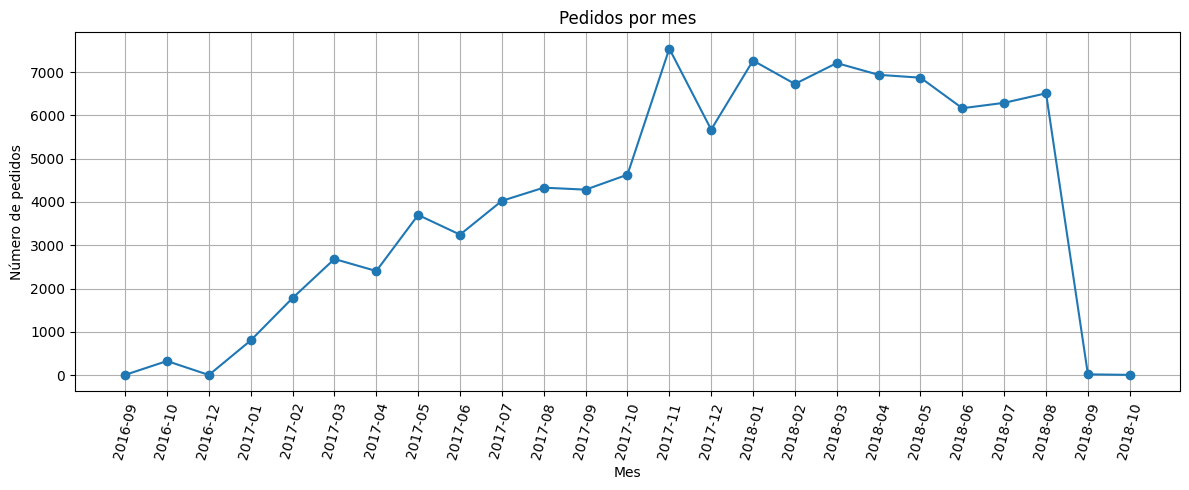

,purchase_month,orders
13,2017-11,7544
14,2017-12,5673
15,2018-01,7269
16,2018-02,6728
17,2018-03,7211
18,2018-04,6939
19,2018-05,6873
20,2018-06,6167
21,2018-07,6292
22,2018-08,6512


In [10]:
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
orders_by_month = orders.groupby('purchase_month').size().reset_index(name='orders')

plt.plot(orders_by_month['purchase_month'], orders_by_month['orders'], marker='o')
plt.title('Pedidos por mes')
plt.xlabel('Mes')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

display(orders_by_month.tail(12))


## 10. Estado de pedidos

Ayuda a entender el flujo operacional y posibles reglas de negocio.


,estado_pedido,cantidad,porcentaje
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


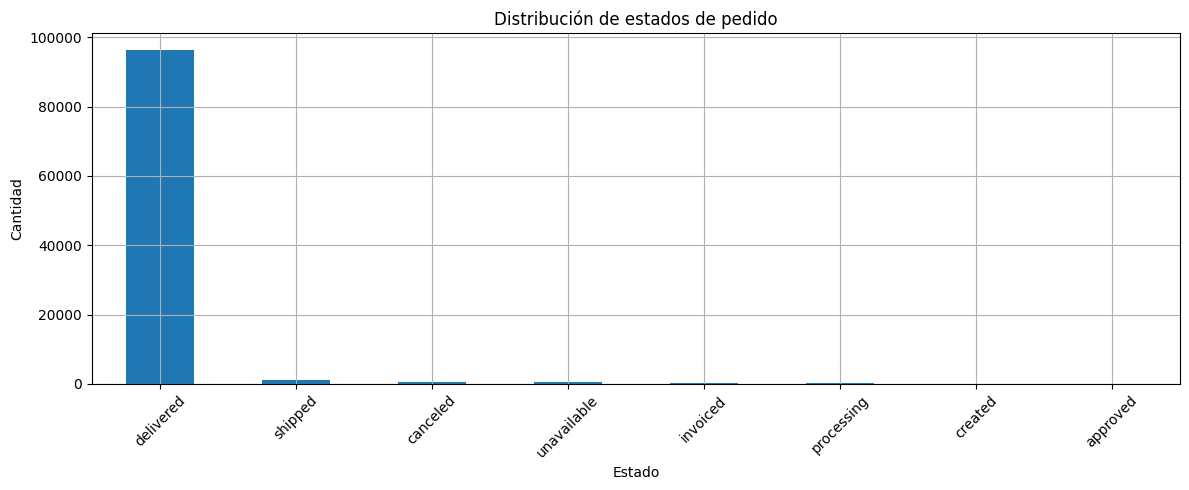

In [11]:
order_status = orders['order_status'].value_counts().reset_index()
order_status.columns = ['estado_pedido', 'cantidad']
order_status['porcentaje'] = (order_status['cantidad'] / order_status['cantidad'].sum() * 100).round(2)

display(order_status)

order_status.set_index('estado_pedido')['cantidad'].plot(kind='bar')
plt.title('Distribución de estados de pedido')
plt.xlabel('Estado')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Análisis de entregas

Se calculan días de entrega, cumplimiento frente a fecha estimada y retrasos.


,indicador,valor
0,Tiempo promedio de entrega,12.09
1,Mediana de entrega,10.00
2,Pedidos entregados tarde,"6,535.00"
3,% pedidos tarde,6.57


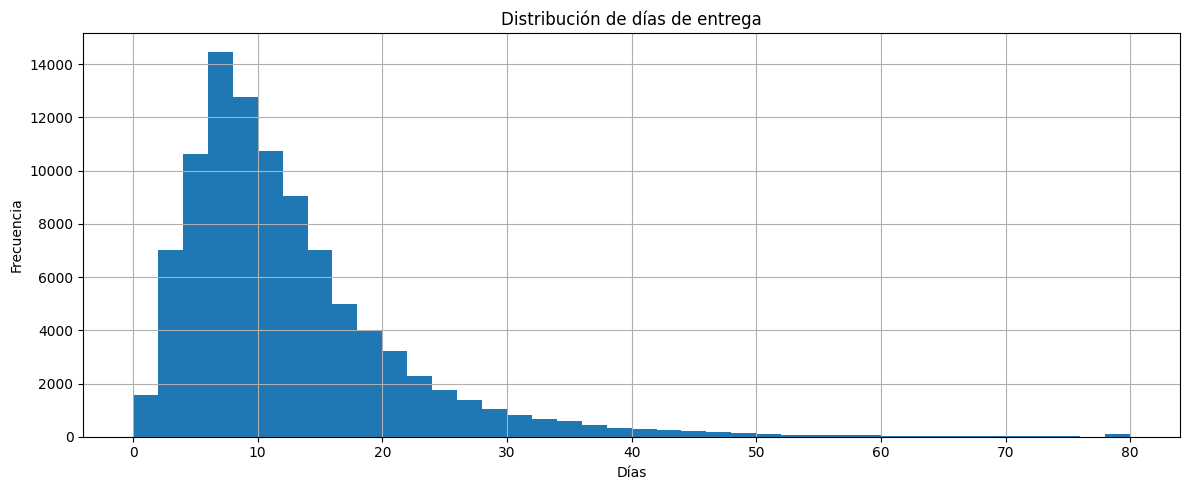

In [12]:
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['delivered_late'] = orders['delay_days'] > 0

delivery_kpis = pd.DataFrame({
    'indicador': [
        'Tiempo promedio de entrega',
        'Mediana de entrega',
        'Pedidos entregados tarde',
        '% pedidos tarde'
    ],
    'valor': [
        round(orders['delivery_days'].mean(), 2),
        round(orders['delivery_days'].median(), 2),
        int(orders['delivered_late'].sum()),
        round(orders['delivered_late'].mean() * 100, 2)
    ]
})

display(delivery_kpis)

orders['delivery_days'].dropna().clip(upper=80).hist(bins=40)
plt.title('Distribución de días de entrega')
plt.xlabel('Días')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


## 12. Análisis de pagos

Información crítica para el módulo transaccional en PostgreSQL.


,payment_type,transacciones,valor_total,valor_promedio,cuotas_promedio,participacion_valor_%
0,credit_card,76795,"12,542,084.19",163.32,3.51,78.34
1,boleto,19784,"2,869,361.27",145.03,1.00,17.92
2,voucher,5775,"379,436.87",65.70,1.00,2.37
3,debit_card,1529,"217,989.79",142.57,1.00,1.36
4,not_defined,3,0.00,0.00,1.00,0.00


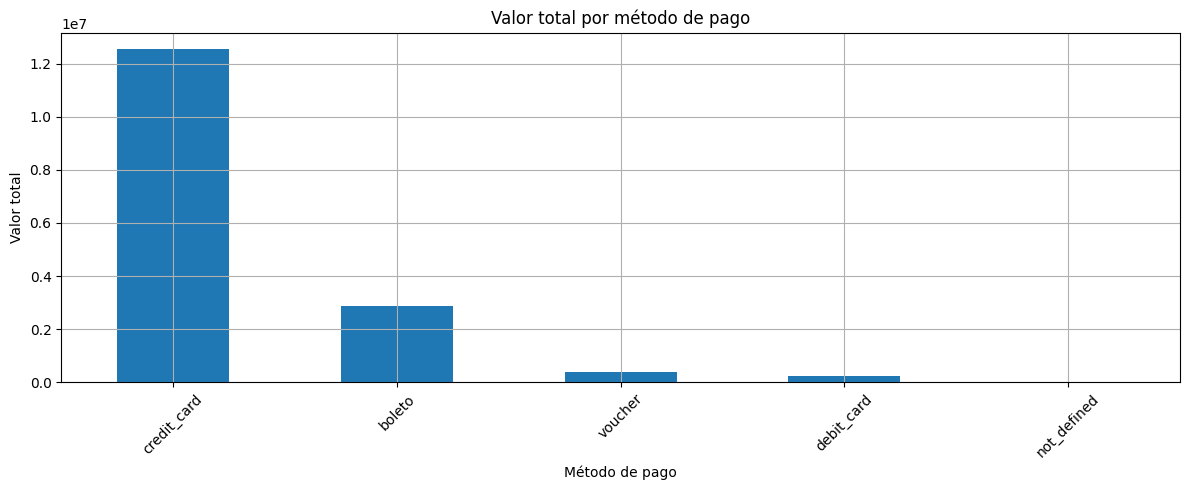

In [13]:
payment_summary = payments.groupby('payment_type').agg(
    transacciones=('order_id', 'count'),
    valor_total=('payment_value', 'sum'),
    valor_promedio=('payment_value', 'mean'),
    cuotas_promedio=('payment_installments', 'mean')
).sort_values('valor_total', ascending=False).reset_index()

payment_summary['participacion_valor_%'] = (payment_summary['valor_total'] / payment_summary['valor_total'].sum() * 100).round(2)
display(payment_summary)

payment_summary.set_index('payment_type')['valor_total'].plot(kind='bar')
plt.title('Valor total por método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Valor total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 13. Análisis comercial: ventas y ticket promedio

Se calcula el valor de venta desde `order_items`: precio + flete. Útil para análisis analítico y decisiones de índices.


,indicador,valor
0,Pedidos con ítems,"98,666.00"
1,Valor total productos,"13,591,643.70"
2,Valor total fletes,"2,251,909.54"
3,Ticket promedio por pedido,160.58
4,Ítems promedio por pedido,1.14


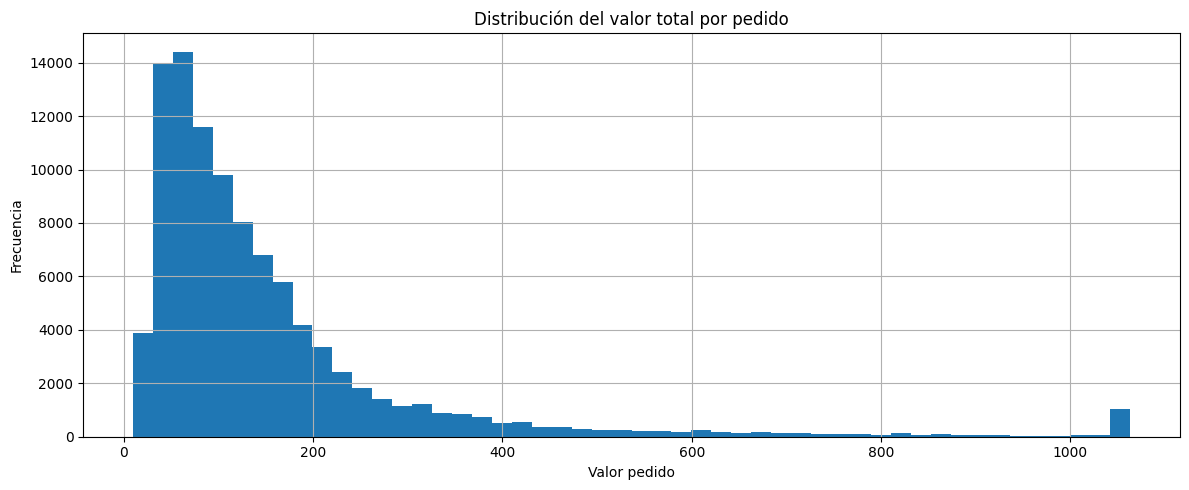

In [14]:
order_items['item_total_value'] = order_items['price'] + order_items['freight_value']

sales_by_order = order_items.groupby('order_id').agg(
    items=('order_item_id', 'count'),
    product_value=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    order_total_value=('item_total_value', 'sum')
).reset_index()

commercial_kpis = pd.DataFrame({
    'indicador': [
        'Pedidos con ítems',
        'Valor total productos',
        'Valor total fletes',
        'Ticket promedio por pedido',
        'Ítems promedio por pedido'
    ],
    'valor': [
        sales_by_order['order_id'].nunique(),
        round(sales_by_order['product_value'].sum(), 2),
        round(sales_by_order['freight_value'].sum(), 2),
        round(sales_by_order['order_total_value'].mean(), 2),
        round(sales_by_order['items'].mean(), 2)
    ]
})

display(commercial_kpis)

sales_by_order['order_total_value'].clip(upper=sales_by_order['order_total_value'].quantile(0.99)).hist(bins=50)
plt.title('Distribución del valor total por pedido')
plt.xlabel('Valor pedido')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


## 14. Análisis de categorías y catálogo

El catálogo puede tener atributos variables; por eso es candidato para MongoDB o para uso de `JSONB` en PostgreSQL según el caso.


,product_category_name,product_category_name_english,items_vendidos,ventas,flete,productos_unicos
0,beleza_saude,health_beauty,9670,"1,258,681.34","182,566.73",2444
1,relogios_presentes,watches_gifts,5991,"1,205,005.68","100,535.93",1329
2,cama_mesa_banho,bed_bath_table,11115,"1,036,988.68","204,693.04",3029
3,esporte_lazer,sports_leisure,8641,"988,048.97","168,607.51",2867
4,informatica_acessorios,computers_accessories,7827,"911,954.32","147,318.08",1639
5,moveis_decoracao,furniture_decor,8334,"729,762.49","172,749.30",2657
6,cool_stuff,cool_stuff,3796,"635,290.85","84,039.10",789
7,utilidades_domesticas,housewares,6964,"632,248.66","146,149.11",2335
8,automotivo,auto,4235,"592,720.11","92,664.21",1900
9,ferramentas_jardim,garden_tools,4347,"485,256.46","98,962.75",753


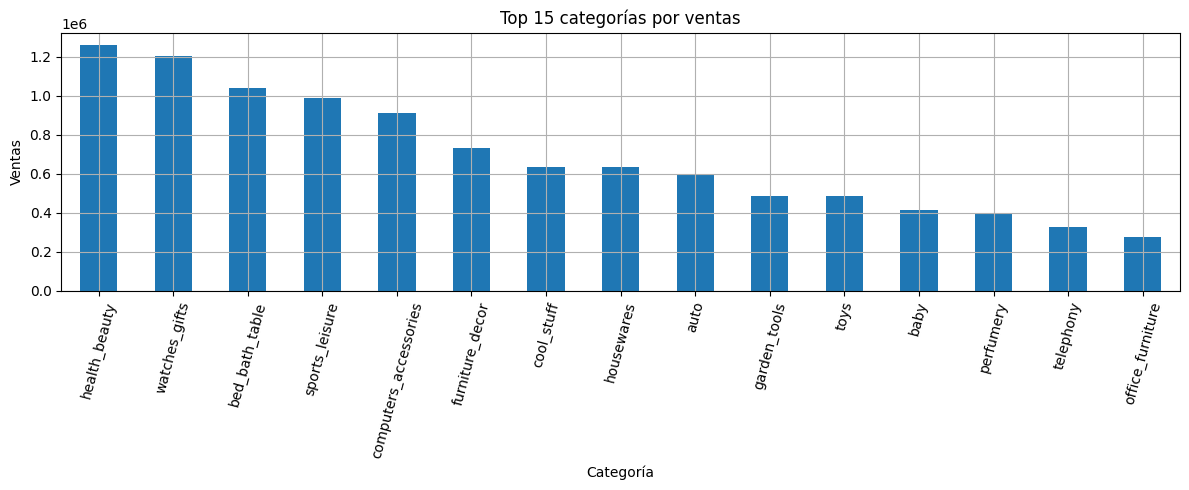

In [15]:
products_en = products.merge(category_translation, on='product_category_name', how='left')

category_sales = order_items.merge(products_en[['product_id', 'product_category_name', 'product_category_name_english']], on='product_id', how='left')
category_sales = category_sales.groupby(['product_category_name', 'product_category_name_english']).agg(
    items_vendidos=('order_item_id', 'count'),
    ventas=('price', 'sum'),
    flete=('freight_value', 'sum'),
    productos_unicos=('product_id', 'nunique')
).sort_values('ventas', ascending=False).reset_index()

display(category_sales.head(20))

category_sales.head(15).set_index('product_category_name_english')['ventas'].plot(kind='bar')
plt.title('Top 15 categorías por ventas')
plt.xlabel('Categoría')
plt.ylabel('Ventas')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## 15. Calidad del catálogo de productos

Identifica campos incompletos que podrían requerir limpieza, enriquecimiento o almacenamiento flexible.


In [16]:
product_quality = products.isnull().sum().reset_index()
product_quality.columns = ['campo', 'nulos']
product_quality['porcentaje_nulos'] = (product_quality['nulos'] / len(products) * 100).round(2)
display(product_quality.sort_values('porcentaje_nulos', ascending=False))

product_numeric = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g',
                   'product_length_cm', 'product_height_cm', 'product_width_cm']
existing_numeric = [c for c in product_numeric if c in products.columns]
display(products[existing_numeric].describe())


,campo,nulos,porcentaje_nulos
1,product_category_name,610,1.85
3,product_description_lenght,610,1.85
2,product_name_lenght,610,1.85
4,product_photos_qty,610,1.85
5,product_weight_g,2,0.01
7,product_height_cm,2,0.01
6,product_length_cm,2,0.01
8,product_width_cm,2,0.01
0,product_id,0,0.00


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,"32,341.00","32,341.00","32,341.00","32,949.00","32,949.00","32,949.00","32,949.00"
mean,48.48,771.50,2.19,"2,276.47",30.82,16.94,23.20
std,10.25,635.12,1.74,"4,282.04",16.91,13.64,12.08
min,5.00,4.00,1.00,0.00,7.00,2.00,6.00
25%,42.00,339.00,1.00,300.00,18.00,8.00,15.00
50%,51.00,595.00,1.00,700.00,25.00,13.00,20.00
75%,57.00,972.00,3.00,"1,900.00",38.00,21.00,30.00
max,76.00,"3,992.00",20.00,"40,425.00",105.00,105.00,118.00


## 16. Análisis de reviews

Las reseñas son candidatas para MongoDB porque combinan datos estructurados —score— con texto variable —comentarios y títulos—.


,review_score,cantidad,con_comentario,con_titulo,porcentaje
0,1,11424,8745,1873,11.51
1,2,3151,2145,478,3.18
2,3,8179,3557,824,8.24
3,4,19142,5976,1735,19.29
4,5,57328,20554,6658,57.78


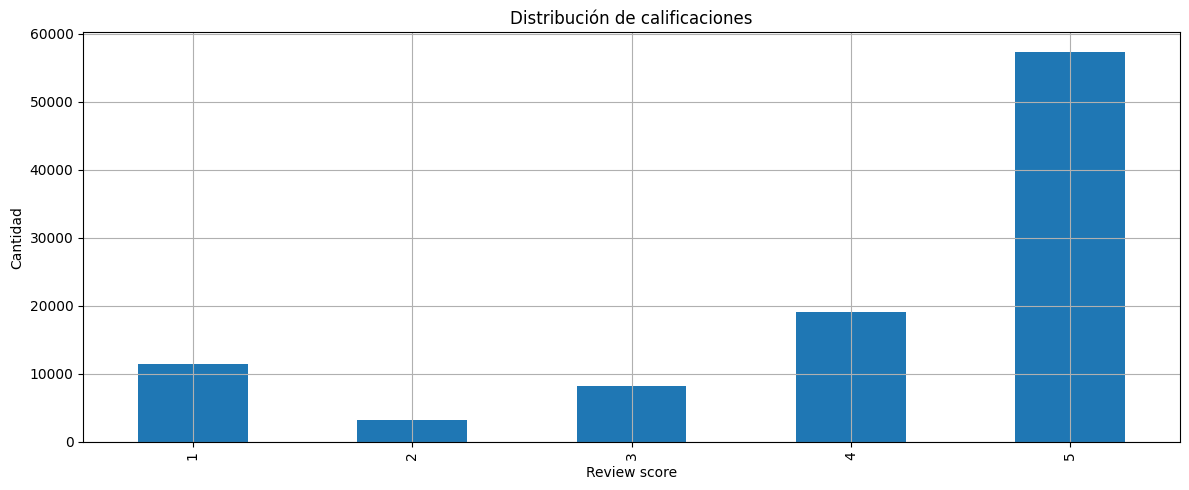

In [17]:
review_summary = reviews.groupby('review_score').agg(
    cantidad=('review_id', 'count'),
    con_comentario=('review_comment_message', lambda x: x.notnull().sum()),
    con_titulo=('review_comment_title', lambda x: x.notnull().sum())
).reset_index()
review_summary['porcentaje'] = (review_summary['cantidad'] / review_summary['cantidad'].sum() * 100).round(2)
display(review_summary)

review_summary.set_index('review_score')['cantidad'].plot(kind='bar')
plt.title('Distribución de calificaciones')
plt.xlabel('Review score')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()


## 17. Análisis geográfico de clientes y vendedores

Permite comprender cobertura territorial y posibles decisiones de segmentación, índices por estado/ciudad o análisis logístico.


,estado,clientes,vendedores
0,AC,81,1
1,AL,413,0
2,AM,148,1
3,AP,68,0
4,BA,3380,19
5,CE,1336,13
6,DF,2140,30
7,ES,2033,23
8,GO,2020,40
9,MA,747,1


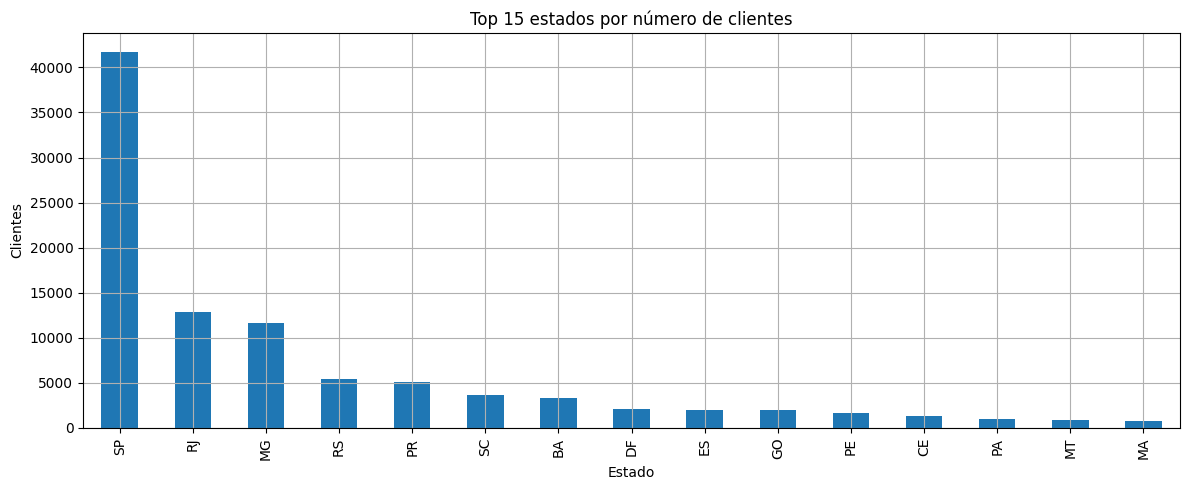

In [18]:
customers_by_state = customers['customer_state'].value_counts().reset_index()
customers_by_state.columns = ['estado', 'clientes']

sellers_by_state = sellers['seller_state'].value_counts().reset_index()
sellers_by_state.columns = ['estado', 'vendedores']

geo_summary = customers_by_state.merge(sellers_by_state, on='estado', how='outer').fillna(0)
geo_summary[['clientes', 'vendedores']] = geo_summary[['clientes', 'vendedores']].astype(int)
display(geo_summary.head(20))

customers_by_state.head(15).set_index('estado')['clientes'].plot(kind='bar')
plt.title('Top 15 estados por número de clientes')
plt.xlabel('Estado')
plt.ylabel('Clientes')
plt.tight_layout()
plt.show()


## 18. Construcción de vista integrada para análisis

Esta vista NO debe usarse como modelo físico normalizado. Sirve como tabla analítica tipo `OrdersFull` para diagnosticar normalización, redundancia y patrones.


In [19]:
orders_full = (
    orders
    .merge(customers, on='customer_id', how='left')
    .merge(sales_by_order, on='order_id', how='left')
)

orders_full = orders_full.merge(
    payments.groupby('order_id').agg(
        payment_value_total=('payment_value', 'sum'),
        payment_methods=('payment_type', lambda x: ', '.join(sorted(x.dropna().unique()))),
        payment_installments_max=('payment_installments', 'max')
    ).reset_index(),
    on='order_id',
    how='left'
)

orders_full = orders_full.merge(
    reviews.groupby('order_id').agg(
        review_score_avg=('review_score', 'mean'),
        review_count=('review_id', 'count')
    ).reset_index(),
    on='order_id',
    how='left'
)

print('OrdersFull:', orders_full.shape)
display(orders_full.head())


OrdersFull: (99441, 25)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,delivery_days,delay_days,delivered_late,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,items,product_value,freight_value,order_total_value,payment_value_total,payment_methods,payment_installments_max,review_score_avg,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8.00,-8.00,False,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,29.99,8.72,38.71,38.71,"credit_card, voucher",1.00,4.00,1.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,13.00,-6.00,False,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,118.70,22.76,141.46,141.46,boleto,1.00,4.00,1.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,9.00,-18.00,False,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,159.90,19.22,179.12,179.12,credit_card,3.00,5.00,1.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,13.00,-13.00,False,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.00,45.00,27.20,72.20,72.20,credit_card,1.00,5.00,1.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2.00,-10.00,False,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.00,19.90,8.72,28.62,28.62,credit_card,1.00,5.00,1.00


## 19. Hallazgos para normalización

La vista `OrdersFull` evidencia por qué no conviene almacenar todo en una sola tabla transaccional.


In [20]:
normalization_findings = pd.DataFrame({
    'forma_normal': ['1FN', '2FN', '3FN', 'Desnormalización estratégica'],
    'hallazgo': [
        'Un pedido puede tener múltiples ítems y múltiples pagos; por tanto, se requieren tablas separadas.',
        'Los atributos de producto dependen de product_id, no de order_id; los atributos de vendedor dependen de seller_id.',
        'La información geográfica como ciudad/estado se repite en clientes y vendedores; puede gestionarse como dimensión o tabla de referencia.',
        'Para analítica, catálogo y reviews, puede convenir agrupar documentos en MongoDB o vistas materializadas.'
    ],
    'decisión_recomendada': [
        'Separar orders, order_items y payments.',
        'Separar products y sellers.',
        'Crear dimensiones o referencias geográficas según necesidad.',
        'Usar MongoDB para productos enriquecidos, reviews y datos analíticos flexibles.'
    ]
})

display(normalization_findings)


,forma_normal,hallazgo,decisión_recomendada
0,1FN,Un pedido puede tener múltiples ítems y múltip...,"Separar orders, order_items y payments."
1,2FN,Los atributos de producto dependen de product_...,Separar products y sellers.
2,3FN,La información geográfica como ciudad/estado s...,Crear dimensiones o referencias geográficas se...
3,Desnormalización estratégica,"Para analítica, catálogo y reviews, puede conv...","Usar MongoDB para productos enriquecidos, revi..."


## 20. Matriz de decisión tecnológica: PostgreSQL vs MongoDB

La decisión se basa en consistencia, estructura de datos, patrones de consulta y criticidad transaccional.


In [21]:
tech_matrix = pd.DataFrame({
    'modulo_entidad': [
        'customers', 'orders', 'order_items', 'payments', 'sellers',
        'products/catalog', 'reviews', 'geolocation', 'logs/user_behavior'
    ],
    'tipo_dato': [
        'Estructurado', 'Transaccional', 'Transaccional', 'Transaccional financiero', 'Estructurado',
        'Semi-estructurado', 'Semi-estructurado', 'Geográfico', 'Semi-estructurado/eventos'
    ],
    'prioridad_CAP': [
        'Consistencia', 'Consistencia', 'Consistencia', 'Consistencia', 'Consistencia',
        'Disponibilidad/Flexibilidad', 'Disponibilidad/Flexibilidad', 'Consulta analítica', 'Disponibilidad'
    ],
    'tecnologia_recomendada': [
        'PostgreSQL', 'PostgreSQL', 'PostgreSQL', 'PostgreSQL', 'PostgreSQL',
        'MongoDB o PostgreSQL JSONB', 'MongoDB', 'PostgreSQL + índices geográficos', 'MongoDB'
    ],
    'justificacion': [
        'Requiere integridad y relaciones con órdenes.',
        'Núcleo transaccional del sistema.',
        'Resuelve relación N:M entre pedidos y productos.',
        'Datos críticos con reglas de validación.',
        'Entidad maestra relacionada con ventas.',
        'Puede variar en atributos, fotos, descripciones y metadatos.',
        'Contiene texto flexible y análisis de experiencia.',
        'Útil para filtros, zonas y análisis territorial.',
        'Alto volumen y esquema cambiante.'
    ]
})

display(tech_matrix)


,modulo_entidad,tipo_dato,prioridad_CAP,tecnologia_recomendada,justificacion
0,customers,Estructurado,Consistencia,PostgreSQL,Requiere integridad y relaciones con órdenes.
1,orders,Transaccional,Consistencia,PostgreSQL,Núcleo transaccional del sistema.
2,order_items,Transaccional,Consistencia,PostgreSQL,Resuelve relación N:M entre pedidos y productos.
3,payments,Transaccional financiero,Consistencia,PostgreSQL,Datos críticos con reglas de validación.
4,sellers,Estructurado,Consistencia,PostgreSQL,Entidad maestra relacionada con ventas.
5,products/catalog,Semi-estructurado,Disponibilidad/Flexibilidad,MongoDB o PostgreSQL JSONB,"Puede variar en atributos, fotos, descripcione..."
6,reviews,Semi-estructurado,Disponibilidad/Flexibilidad,MongoDB,Contiene texto flexible y análisis de experien...
7,geolocation,Geográfico,Consulta analítica,PostgreSQL + índices geográficos,"Útil para filtros, zonas y análisis territorial."
8,logs/user_behavior,Semi-estructurado/eventos,Disponibilidad,MongoDB,Alto volumen y esquema cambiante.


## 21. Recomendaciones de diseño físico preliminar

Estas recomendaciones conectan el EDA con la implementación de base de datos.


In [22]:
physical_design = pd.DataFrame({
    'elemento': [
        'PK orders', 'FK orders.customer_id', 'Índice temporal orders', 'Índice order_items.product_id',
        'Índice payments.order_id', 'Particionamiento orders', 'Documento MongoDB product_catalog',
        'Documento MongoDB reviews'
    ],
    'recomendacion': [
        'order_id como PRIMARY KEY.',
        'customer_id como FOREIGN KEY hacia customers.',
        'Crear índice en order_purchase_timestamp para consultas por fecha.',
        'Crear índice para consultas por producto/categoría.',
        'Crear índice para reconciliación de pagos por pedido.',
        'Evaluar particionamiento mensual o anual si el volumen crece.',
        'Incluir atributos de producto, categoría traducida, métricas de ventas y metadatos.',
        'Almacenar score, título, mensaje, fechas y referencia a order_id/product_id cuando aplique.'
    ]
})

display(physical_design)


,elemento,recomendacion
0,PK orders,order_id como PRIMARY KEY.
1,FK orders.customer_id,customer_id como FOREIGN KEY hacia customers.
2,Índice temporal orders,Crear índice en order_purchase_timestamp para ...
3,Índice order_items.product_id,Crear índice para consultas por producto/categ...
4,Índice payments.order_id,Crear índice para reconciliación de pagos por ...
5,Particionamiento orders,Evaluar particionamiento mensual o anual si el...
6,Documento MongoDB product_catalog,"Incluir atributos de producto, categoría tradu..."
7,Documento MongoDB reviews,"Almacenar score, título, mensaje, fechas y ref..."


## 22. Conclusiones del EDA

1. El dataset tiene una estructura predominantemente relacional, por lo que PostgreSQL es adecuado para pedidos, pagos, clientes, vendedores e ítems de pedido.

2. La tabla `orders` funciona como núcleo transaccional y se conecta con clientes, pagos, reseñas e ítems.

3. Existen datos semi-estructurados y de alta variabilidad, especialmente en catálogo y reviews, que pueden beneficiarse de MongoDB.

4. La normalización hasta 3FN es recomendable para el módulo transaccional, evitando redundancia e inconsistencias.

5. La desnormalización estratégica es conveniente para análisis, búsquedas rápidas, catálogo enriquecido y experiencia del cliente.

6. El análisis temporal justifica índices sobre fechas y, en escenarios de mayor volumen, particionamiento por periodo.

7. El análisis de calidad de datos muestra campos nulos que deben documentarse y tratarse antes de imponer restricciones fuertes.

8. La arquitectura híbrida PostgreSQL + MongoDB se justifica porque combina integridad transaccional con flexibilidad analítica.


---
# 24. EDA avanzado orientado a arquitectura
Esta sección complementa el análisis anterior con validaciones técnicas para sustentar normalización, particionamiento, índices, restricciones y distribución PostgreSQL/MongoDB.

## 24.1 Perfilamiento reutilizable de tablas y campos

In [23]:
def profile_table(df, table_name):
    total_rows = len(df)
    return pd.DataFrame({
        'tabla': table_name,
        'columna': df.columns,
        'tipo_dato': [str(df[col].dtype) for col in df.columns],
        'nulos': [int(df[col].isnull().sum()) for col in df.columns],
        'porcentaje_nulos': [round(df[col].isnull().mean() * 100, 2) for col in df.columns],
        'valores_unicos': [int(df[col].nunique(dropna=True)) for col in df.columns],
        'cardinalidad_relativa': [round(df[col].nunique(dropna=True) / total_rows, 4) if total_rows > 0 else 0 for col in df.columns],
        'ejemplo_1': [df[col].dropna().iloc[0] if df[col].dropna().shape[0] > 0 else None for col in df.columns]
    })

advanced_dictionary = pd.concat([profile_table(df, name) for name, df in data.items()], ignore_index=True)
display(advanced_dictionary.sort_values(['tabla', 'porcentaje_nulos'], ascending=[True, False]))

,tabla,columna,tipo_dato,nulos,porcentaje_nulos,valores_unicos,cardinalidad_relativa,ejemplo_1
55,category_translation,product_category_name,object,0,0.00,71,1.00,beleza_saude
56,category_translation,product_category_name_english,object,0,0.00,71,1.00,health_beauty
0,customers,customer_id,object,0,0.00,99441,1.00,06b8999e2fba1a1fbc88172c00ba8bc7
1,customers,customer_unique_id,object,0,0.00,96096,0.97,861eff4711a542e4b93843c6dd7febb0
2,customers,customer_zip_code_prefix,int64,0,0.00,14994,0.15,14409
3,customers,customer_city,object,0,0.00,4119,0.04,franca
4,customers,customer_state,object,0,0.00,27,0.00,SP
5,geolocation,geolocation_zip_code_prefix,int64,0,0.00,19015,0.02,1037
6,geolocation,geolocation_lat,float64,0,0.00,717360,0.72,-23.55
7,geolocation,geolocation_lng,float64,0,0.00,717613,0.72,-46.64


## 24.2 Score de calidad por tabla
Un score bajo indica mayor necesidad de limpieza antes de migrar o imponer restricciones.

In [24]:
quality_rows = []
for name, df in data.items():
    total_cells = df.shape[0] * df.shape[1]
    null_rate = df.isnull().sum().sum() / total_cells if total_cells > 0 else 0
    duplicate_rate = df.duplicated().mean() if len(df) > 0 else 0
    empty_string_rate = (df.astype(str).apply(lambda s: s.str.strip().eq('').sum()).sum() / total_cells) if total_cells > 0 else 0
    quality_score = round(100 * (1 - min(1, null_rate + duplicate_rate + empty_string_rate)), 2)
    quality_rows.append({
        'tabla': name, 'filas': df.shape[0], 'columnas': df.shape[1],
        'tasa_nulos_%': round(null_rate * 100, 2),
        'tasa_duplicados_exactos_%': round(duplicate_rate * 100, 2),
        'tasa_cadenas_vacias_%': round(empty_string_rate * 100, 2),
        'score_calidad_estimado': quality_score
    })
quality_score_df = pd.DataFrame(quality_rows).sort_values('score_calidad_estimado')
display(quality_score_df)

,tabla,filas,columnas,tasa_nulos_%,tasa_duplicados_exactos_%,tasa_cadenas_vacias_%,score_calidad_estimado
1,geolocation,1000163,5,0.00,26.18,0.00,73.82
4,reviews,99224,7,21.01,0.00,0.00,78.99
5,orders,99441,12,0.91,0.00,0.00,99.09
6,products,32951,9,0.83,0.00,0.00,99.17
3,payments,103886,5,0.00,0.00,0.00,100.00
2,order_items,112650,8,0.00,0.00,0.00,100.00
0,customers,99441,5,0.00,0.00,0.00,100.00
7,sellers,3095,4,0.00,0.00,0.00,100.00
8,category_translation,71,2,0.00,0.00,0.00,100.00


## 24.3 Validación avanzada de claves primarias candidatas

In [25]:
pk_candidates = {
    'customers': [['customer_id'], ['customer_unique_id']],
    'orders': [['order_id']],
    'order_items': [['order_id', 'order_item_id']],
    'payments': [['order_id', 'payment_sequential']],
    'reviews': [['review_id']],
    'products': [['product_id']],
    'sellers': [['seller_id']],
    'category_translation': [['product_category_name']],
    'geolocation': [['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']]
}
pk_validation = []
for table_name, candidate_sets in pk_candidates.items():
    df = data[table_name]
    for cols in candidate_sets:
        if not all(c in df.columns for c in cols):
            continue
        null_rows = int(df[cols].isnull().any(axis=1).sum())
        duplicated_rows = int(df.duplicated(subset=cols).sum())
        pk_validation.append({
            'tabla': table_name,
            'clave_candidata': ' + '.join(cols),
            'filas_con_nulos_en_clave': null_rows,
            'duplicados_en_clave': duplicated_rows,
            'apta_como_pk': null_rows == 0 and duplicated_rows == 0
        })
pk_validation_df = pd.DataFrame(pk_validation)
display(pk_validation_df)

,tabla,clave_candidata,filas_con_nulos_en_clave,duplicados_en_clave,apta_como_pk
0,customers,customer_id,0,0,True
1,customers,customer_unique_id,0,3345,False
2,orders,order_id,0,0,True
3,order_items,order_id + order_item_id,0,0,True
4,payments,order_id + payment_sequential,0,0,True
5,reviews,review_id,0,814,False
6,products,product_id,0,0,True
7,sellers,seller_id,0,0,True
8,category_translation,product_category_name,0,0,True
9,geolocation,geolocation_zip_code_prefix + geolocation_lat ...,0,280009,False


## 24.4 Inferencia de cardinalidades reales

In [26]:
cardinality_rows = []
for src_table, src_col, dst_table, dst_col in relationships:
    src, dst = data[src_table], data[dst_table]
    if src_col not in src.columns or dst_col not in dst.columns:
        continue
    src_per_key = src.groupby(src_col).size()
    dst_per_key = dst.groupby(dst_col).size()
    max_src = int(src_per_key.max()) if len(src_per_key) else 0
    max_dst = int(dst_per_key.max()) if len(dst_per_key) else 0
    if max_src > 1 and max_dst == 1:
        card = 'N:1'
    elif max_src == 1 and max_dst > 1:
        card = '1:N'
    elif max_src == 1 and max_dst == 1:
        card = '1:1'
    else:
        card = 'N:M o clave destino no única'
    cardinality_rows.append({
        'origen': f'{src_table}.{src_col}', 'destino': f'{dst_table}.{dst_col}',
        'max_origen_por_clave': max_src, 'max_destino_por_clave': max_dst,
        'cardinalidad_observada': card
    })
cardinality_df = pd.DataFrame(cardinality_rows)
display(cardinality_df)

,origen,destino,max_origen_por_clave,max_destino_por_clave,cardinalidad_observada
0,orders.customer_id,customers.customer_id,1,1,1:1
1,order_items.order_id,orders.order_id,21,1,N:1
2,order_items.product_id,products.product_id,527,1,N:1
3,order_items.seller_id,sellers.seller_id,2033,1,N:1
4,payments.order_id,orders.order_id,29,1,N:1
5,reviews.order_id,orders.order_id,3,1,N:1
6,products.product_category_name,category_translation.product_category_name,3029,1,N:1


## 24.5 Validaciones de anomalías numéricas

In [27]:
numeric_checks = []
for table_name, df in data.items():
    for col in df.select_dtypes(include=[np.number]).columns:
        s = df[col]
        numeric_checks.append({
            'tabla': table_name, 'columna': col,
            'min': s.min(), 'p01': s.quantile(0.01), 'mediana': s.median(),
            'promedio': s.mean(), 'p99': s.quantile(0.99), 'max': s.max(),
            'valores_negativos': int((s < 0).sum()), 'valores_cero': int((s == 0).sum())
        })
numeric_checks_df = pd.DataFrame(numeric_checks)
display(numeric_checks_df)

,tabla,columna,min,p01,mediana,promedio,p99,max,valores_negativos,valores_cero
0,customers,customer_zip_code_prefix,"1,003.00","1,327.00","24,416.00","35,137.47","97,513.00","99,990.00",0,0
1,geolocation,geolocation_zip_code_prefix,"1,001.00","1,318.00","26,530.00","36,574.17","98,010.00","99,990.00",0,0
2,geolocation,geolocation_lat,-36.61,-30.10,-22.92,-21.18,-2.50,45.07,998827,0
3,geolocation,geolocation_lng,-101.47,-57.65,-46.64,-46.39,-34.94,121.11,1000160,0
4,order_items,order_item_id,1.00,1.00,1.00,1.20,4.00,21.00,0,0
5,order_items,price,0.85,9.99,74.99,120.65,890.00,"6,735.00",0,0
6,order_items,freight_value,0.00,4.42,16.26,19.99,84.52,409.68,0,383
7,order_items,item_total_value,6.08,20.86,92.32,140.64,923.22,"6,929.31",0,0
8,payments,payment_sequential,1.00,1.00,1.00,1.09,3.00,29.00,0,0
9,payments,payment_installments,0.00,1.00,1.00,2.85,10.00,24.00,0,2


## 24.6 Patrones de acceso esperados e índices sugeridos

In [28]:
access_patterns = pd.DataFrame({
    'caso_de_uso': [
        'Consultar historial de pedidos por cliente', 'Consultar detalle completo de un pedido',
        'Analizar ventas por mes', 'Analizar ventas por categoría',
        'Consultar reviews de un producto', 'Consultar catálogo con atributos variables',
        'Analizar desempeño de vendedores por región', 'Analizar cumplimiento de entregas'
    ],
    'tablas_involucradas': [
        'customers + orders', 'orders + order_items + payments + reviews', 'orders + order_items',
        'order_items + products + category_translation', 'reviews + orders + order_items + products',
        'products', 'sellers + order_items + orders', 'orders'
    ],
    'tipo_consulta': ['Transaccional','Transaccional','Analítica','Analítica','Analítica / experiencia','Lectura flexible','Analítica','Operacional'],
    'tecnologia_recomendada': ['PostgreSQL','PostgreSQL','PostgreSQL con vista/materialización','PostgreSQL o MongoDB','MongoDB','MongoDB','PostgreSQL','PostgreSQL'],
    'indice_o_modelo_sugerido': [
        'idx_orders_customer_id', 'idx_order_items_order_id + idx_payments_order_id',
        'idx_orders_purchase_timestamp o particionamiento por fecha', 'idx_products_category + vista analítica',
        'Documento embebido por product_id o índice reviews.order_id', 'Documento product_catalog con atributos flexibles',
        'idx_order_items_seller_id + idx_sellers_state', 'idx_orders_delivery_dates'
    ]
})
display(access_patterns)

,caso_de_uso,tablas_involucradas,tipo_consulta,tecnologia_recomendada,indice_o_modelo_sugerido
0,Consultar historial de pedidos por cliente,customers + orders,Transaccional,PostgreSQL,idx_orders_customer_id
1,Consultar detalle completo de un pedido,orders + order_items + payments + reviews,Transaccional,PostgreSQL,idx_order_items_order_id + idx_payments_order_id
2,Analizar ventas por mes,orders + order_items,Analítica,PostgreSQL con vista/materialización,idx_orders_purchase_timestamp o particionamien...
3,Analizar ventas por categoría,order_items + products + category_translation,Analítica,PostgreSQL o MongoDB,idx_products_category + vista analítica
4,Consultar reviews de un producto,reviews + orders + order_items + products,Analítica / experiencia,MongoDB,Documento embebido por product_id o índice rev...
5,Consultar catálogo con atributos variables,products,Lectura flexible,MongoDB,Documento product_catalog con atributos flexibles
6,Analizar desempeño de vendedores por región,sellers + order_items + orders,Analítica,PostgreSQL,idx_order_items_seller_id + idx_sellers_state
7,Analizar cumplimiento de entregas,orders,Operacional,PostgreSQL,idx_orders_delivery_dates


## 24.7 Reglas de integridad y diseño físico preliminar

In [29]:
integrity_rules = pd.DataFrame({
    'tabla': ['orders','order_items','payments','reviews','products','customers','sellers'],
    'campo_regla': ['order_status','price / freight_value','payment_value','review_score','product_weight_g / dimensiones','customer_state','seller_state'],
    'regla_sugerida': [
        'CHECK order_status IN valores válidos observados',
        'CHECK price >= 0 AND freight_value >= 0',
        'CHECK payment_value >= 0',
        'CHECK review_score BETWEEN 1 AND 5',
        'CHECK valores numéricos >= 0 cuando no sean nulos',
        'NOT NULL si se confirma obligatoriedad de ubicación',
        'NOT NULL si se confirma obligatoriedad de ubicación'
    ],
    'justificacion': [
        'Evita estados no controlados.', 'Evita montos negativos en ventas/logística.',
        'Preserva integridad financiera.', 'La escala de evaluación está acotada.',
        'Evita inconsistencias físicas del catálogo.', 'Permite análisis geográfico.', 'Permite análisis geográfico.'
    ]
})
display(integrity_rules)

,tabla,campo_regla,regla_sugerida,justificacion
0,orders,order_status,CHECK order_status IN valores válidos observados,Evita estados no controlados.
1,order_items,price / freight_value,CHECK price >= 0 AND freight_value >= 0,Evita montos negativos en ventas/logística.
2,payments,payment_value,CHECK payment_value >= 0,Preserva integridad financiera.
3,reviews,review_score,CHECK review_score BETWEEN 1 AND 5,La escala de evaluación está acotada.
4,products,product_weight_g / dimensiones,CHECK valores numéricos >= 0 cuando no sean nulos,Evita inconsistencias físicas del catálogo.
5,customers,customer_state,NOT NULL si se confirma obligatoriedad de ubic...,Permite análisis geográfico.
6,sellers,seller_state,NOT NULL si se confirma obligatoriedad de ubic...,Permite análisis geográfico.


## 24.8 Diseño documental preliminar para MongoDB

In [30]:
mongodb_design = pd.DataFrame({
    'coleccion': ['product_catalog', 'product_reviews', 'customer_behavior_logs'],
    'clave_documento': ['product_id', 'product_id', 'customer_unique_id o session_id'],
    'estructura_sugerida': [
        '{ product_id, category, dimensions, weight, attributes, sellers_summary }',
        '{ product_id, avg_score, reviews: [{review_id, order_id, score, title, message, date}] }',
        '{ customer_id, events: [{event_type, timestamp, product_id, metadata}] }'
    ],
    'motivo': [
        'Catálogo con atributos variables y consultas frecuentes de lectura.',
        'Reviews combinan datos estructurados y texto variable.',
        'Los logs tienen alto volumen y estructura cambiante.'
    ],
    'riesgo': [
        'Duplicidad frente a PostgreSQL si no hay sincronización.',
        'Documentos grandes si un producto acumula muchas reseñas.',
        'Crecimiento acelerado y necesidad de retención.'
    ]
})
display(mongodb_design)

sample_product_doc = {
    'product_id': 'example_product_id',
    'category': {'name_pt': 'informatica_acessorios', 'name_en': 'computers_accessories'},
    'physical_attributes': {'weight_g': 500, 'length_cm': 20, 'height_cm': 10, 'width_cm': 15},
    'commercial_summary': {'total_items_sold': 120, 'average_price': 89.90, 'average_freight': 14.50},
    'review_summary': {'average_score': 4.3, 'review_count': 38},
    'updated_at': 'YYYY-MM-DD'
}
sample_product_doc

,coleccion,clave_documento,estructura_sugerida,motivo,riesgo
0,product_catalog,product_id,"{ product_id, category, dimensions, weight, at...",Catálogo con atributos variables y consultas f...,Duplicidad frente a PostgreSQL si no hay sincr...
1,product_reviews,product_id,"{ product_id, avg_score, reviews: [{review_id,...",Reviews combinan datos estructurados y texto v...,Documentos grandes si un producto acumula much...
2,customer_behavior_logs,customer_unique_id o session_id,"{ customer_id, events: [{event_type, timestamp...",Los logs tienen alto volumen y estructura camb...,Crecimiento acelerado y necesidad de retención.


{'product_id': 'example_product_id',
 'category': {'name_pt': 'informatica_acessorios',
  'name_en': 'computers_accessories'},
 'physical_attributes': {'weight_g': 500,
  'length_cm': 20,
  'height_cm': 10,
  'width_cm': 15},
 'commercial_summary': {'total_items_sold': 120,
  'average_price': 89.9,
  'average_freight': 14.5},
 'review_summary': {'average_score': 4.3, 'review_count': 38},
 'updated_at': 'YYYY-MM-DD'}

## 24.9 DDL e índices preliminares para PostgreSQL

In [31]:
ddl_postgresql = """
CREATE TABLE customers (
    customer_id VARCHAR PRIMARY KEY,
    customer_unique_id VARCHAR NOT NULL,
    customer_zip_code_prefix INTEGER,
    customer_city VARCHAR,
    customer_state CHAR(2)
);

CREATE TABLE orders (
    order_id VARCHAR PRIMARY KEY,
    customer_id VARCHAR NOT NULL REFERENCES customers(customer_id),
    order_status VARCHAR NOT NULL,
    order_purchase_timestamp TIMESTAMP,
    order_approved_at TIMESTAMP,
    order_delivered_carrier_date TIMESTAMP,
    order_delivered_customer_date TIMESTAMP,
    order_estimated_delivery_date TIMESTAMP
);

CREATE TABLE products (
    product_id VARCHAR PRIMARY KEY,
    product_category_name VARCHAR,
    product_name_length INTEGER,
    product_description_length INTEGER,
    product_photos_qty INTEGER,
    product_weight_g NUMERIC CHECK (product_weight_g >= 0),
    product_length_cm NUMERIC CHECK (product_length_cm >= 0),
    product_height_cm NUMERIC CHECK (product_height_cm >= 0),
    product_width_cm NUMERIC CHECK (product_width_cm >= 0)
);

CREATE TABLE sellers (
    seller_id VARCHAR PRIMARY KEY,
    seller_zip_code_prefix INTEGER,
    seller_city VARCHAR,
    seller_state CHAR(2)
);

CREATE TABLE order_items (
    order_id VARCHAR REFERENCES orders(order_id),
    order_item_id INTEGER,
    product_id VARCHAR REFERENCES products(product_id),
    seller_id VARCHAR REFERENCES sellers(seller_id),
    shipping_limit_date TIMESTAMP,
    price NUMERIC CHECK (price >= 0),
    freight_value NUMERIC CHECK (freight_value >= 0),
    PRIMARY KEY (order_id, order_item_id)
);

CREATE TABLE payments (
    order_id VARCHAR REFERENCES orders(order_id),
    payment_sequential INTEGER,
    payment_type VARCHAR,
    payment_installments INTEGER,
    payment_value NUMERIC CHECK (payment_value >= 0),
    PRIMARY KEY (order_id, payment_sequential)
);

CREATE TABLE reviews (
    review_id VARCHAR PRIMARY KEY,
    order_id VARCHAR REFERENCES orders(order_id),
    review_score INTEGER CHECK (review_score BETWEEN 1 AND 5),
    review_comment_title TEXT,
    review_comment_message TEXT,
    review_creation_date TIMESTAMP,
    review_answer_timestamp TIMESTAMP
);
"""
print(ddl_postgresql)

index_recommendations = pd.DataFrame({
    'indice': [
        'idx_orders_customer_id','idx_orders_purchase_timestamp','idx_order_items_order_id',
        'idx_order_items_product_id','idx_order_items_seller_id','idx_payments_order_id',
        'idx_reviews_order_id','idx_products_category','idx_customers_state_city','idx_sellers_state_city'
    ],
    'ddl': [
        'CREATE INDEX idx_orders_customer_id ON orders(customer_id);',
        'CREATE INDEX idx_orders_purchase_timestamp ON orders(order_purchase_timestamp);',
        'CREATE INDEX idx_order_items_order_id ON order_items(order_id);',
        'CREATE INDEX idx_order_items_product_id ON order_items(product_id);',
        'CREATE INDEX idx_order_items_seller_id ON order_items(seller_id);',
        'CREATE INDEX idx_payments_order_id ON payments(order_id);',
        'CREATE INDEX idx_reviews_order_id ON reviews(order_id);',
        'CREATE INDEX idx_products_category ON products(product_category_name);',
        'CREATE INDEX idx_customers_state_city ON customers(customer_state, customer_city);',
        'CREATE INDEX idx_sellers_state_city ON sellers(seller_state, seller_city);'
    ]
})
display(index_recommendations)


CREATE TABLE customers (
    customer_id VARCHAR PRIMARY KEY,
    customer_unique_id VARCHAR NOT NULL,
    customer_zip_code_prefix INTEGER,
    customer_city VARCHAR,
    customer_state CHAR(2)
);

CREATE TABLE orders (
    order_id VARCHAR PRIMARY KEY,
    customer_id VARCHAR NOT NULL REFERENCES customers(customer_id),
    order_status VARCHAR NOT NULL,
    order_purchase_timestamp TIMESTAMP,
    order_approved_at TIMESTAMP,
    order_delivered_carrier_date TIMESTAMP,
    order_delivered_customer_date TIMESTAMP,
    order_estimated_delivery_date TIMESTAMP
);

CREATE TABLE products (
    product_id VARCHAR PRIMARY KEY,
    product_category_name VARCHAR,
    product_name_length INTEGER,
    product_description_length INTEGER,
    product_photos_qty INTEGER,
    product_weight_g NUMERIC CHECK (product_weight_g >= 0),
    product_length_cm NUMERIC CHECK (product_length_cm >= 0),
    product_height_cm NUMERIC CHECK (product_height_cm >= 0),
    product_width_cm NUMERIC CHECK (product_wid

,indice,ddl
0,idx_orders_customer_id,CREATE INDEX idx_orders_customer_id ON orders(...
1,idx_orders_purchase_timestamp,CREATE INDEX idx_orders_purchase_timestamp ON ...
2,idx_order_items_order_id,CREATE INDEX idx_order_items_order_id ON order...
3,idx_order_items_product_id,CREATE INDEX idx_order_items_product_id ON ord...
4,idx_order_items_seller_id,CREATE INDEX idx_order_items_seller_id ON orde...
5,idx_payments_order_id,CREATE INDEX idx_payments_order_id ON payments...
6,idx_reviews_order_id,CREATE INDEX idx_reviews_order_id ON reviews(o...
7,idx_products_category,CREATE INDEX idx_products_category ON products...
8,idx_customers_state_city,CREATE INDEX idx_customers_state_city ON custo...
9,idx_sellers_state_city,CREATE INDEX idx_sellers_state_city ON sellers...


## 24.10 Riesgos técnicos y mitigación

In [32]:
risk_matrix = pd.DataFrame({
    'riesgo': [
        'Fechas de entrega nulas o inconsistentes', 'Reviews sin comentario textual',
        'Categorías de productos incompletas', 'Geolocation con alta granularidad y duplicados',
        'Consultas analíticas costosas por múltiples JOINs', 'Duplicidad entre PostgreSQL y MongoDB'
    ],
    'impacto': [
        'Afecta métricas logísticas y cumplimiento.', 'Limita análisis de texto, pero no el score.',
        'Afecta análisis de catálogo y segmentación.', 'Puede inflar tamaño de tablas.',
        'Puede afectar rendimiento en dashboards.', 'Puede generar inconsistencias entre fuentes.'
    ],
    'mitigacion': [
        'Permitir NULL y validar según estado del pedido.', 'Separar score estructurado del comentario textual.',
        'Enriquecer con category_translation y controlar nulos.', 'Deduplicar por zip_code_prefix y agregar geográficamente.',
        'Usar vistas materializadas o colecciones MongoDB.', 'Definir ETL/ELT, timestamps y fuente maestra.'
    ],
    'prioridad': ['Alta','Media','Media','Media','Alta','Alta']
})
display(risk_matrix)

,riesgo,impacto,mitigacion,prioridad
0,Fechas de entrega nulas o inconsistentes,Afecta métricas logísticas y cumplimiento.,Permitir NULL y validar según estado del pedido.,Alta
1,Reviews sin comentario textual,"Limita análisis de texto, pero no el score.",Separar score estructurado del comentario text...,Media
2,Categorías de productos incompletas,Afecta análisis de catálogo y segmentación.,Enriquecer con category_translation y controla...,Media
3,Geolocation con alta granularidad y duplicados,Puede inflar tamaño de tablas.,Deduplicar por zip_code_prefix y agregar geogr...,Media
4,Consultas analíticas costosas por múltiples JOINs,Puede afectar rendimiento en dashboards.,Usar vistas materializadas o colecciones MongoDB.,Alta
5,Duplicidad entre PostgreSQL y MongoDB,Puede generar inconsistencias entre fuentes.,"Definir ETL/ELT, timestamps y fuente maestra.",Alta


## 24.11 Exportación de artefactos del EDA

In [36]:
import os
import pandas as pd

OUTPUT_PATH = './eda_outputs'
os.makedirs(OUTPUT_PATH, exist_ok=True)

exports = {
    'summary_tables.csv': summary_df,
    'advanced_dictionary.csv': advanced_dictionary,
    'quality_score.csv': quality_score_df,
    'pk_validation.csv': pk_validation_df,
    'relationship_report.csv': relationship_report,
    'cardinality_report.csv': cardinality_df,
    'tech_matrix.csv': tech_matrix,
    'physical_design.csv': physical_design,
    'access_patterns.csv': access_patterns,
    'index_recommendations.csv': index_recommendations,
    'risk_matrix.csv': risk_matrix
}

for filename, obj in exports.items():
    if isinstance(obj, pd.DataFrame):
        df_export = obj
    else:
        df_export = pd.DataFrame(obj)

    df_export.to_csv(
        os.path.join(OUTPUT_PATH, filename),
        index=False,
        encoding='utf-8-sig'
    )

print(f'Artefactos exportados en: {OUTPUT_PATH}')

for filename in exports.keys():
    print('-', filename)

Artefactos exportados en: ./eda_outputs
- summary_tables.csv
- advanced_dictionary.csv
- quality_score.csv
- pk_validation.csv
- relationship_report.csv
- cardinality_report.csv
- tech_matrix.csv
- physical_design.csv
- access_patterns.csv
- index_recommendations.csv
- risk_matrix.csv


# 25. Conclusión ejecutiva reforzada
El EDA evidencia que el dataset Olist tiene una base predominantemente relacional, con `orders` como núcleo transaccional y relaciones claras hacia clientes, pagos, ítems, productos, vendedores y reseñas. Esta estructura justifica el uso de **PostgreSQL** para procesos críticos donde se requiere integridad referencial, consistencia ACID y control transaccional.

El catálogo de productos, las reseñas y los posibles logs de comportamiento presentan características más flexibles, variables y orientadas a lectura analítica. Por esta razón, estos módulos pueden beneficiarse de **MongoDB**, especialmente mediante documentos desnormalizados, resúmenes por producto y estructuras flexibles para atributos variables.

Se recomienda normalizar el núcleo transaccional hasta 3FN, definir claves primarias y foráneas con base en validaciones de unicidad, crear índices sobre campos de relación y fechas, considerar particionamiento temporal para `orders` si el volumen crece, y evitar duplicidad no controlada mediante una estrategia clara de sincronización PostgreSQL → MongoDB.

---
## 25. Transformaciones a Tipos Avanzados de PostgreSQL

La guía de la Unidad 2 exige demostrar las siguientes transformaciones explícitas sobre el dataset Olist, justificando el uso de cada tipo avanzado frente a la alternativa relacional tradicional.

| Transformación | Tipo Avanzado | Alternativa descartada |
|---|---|---|
| `product_specifications` | `JSONB` | Columnas separadas por atributo |
| `product_photos` | `TEXT[]` | Tabla `product_photos` con JOIN |
| `promotion_period` | `TSTZRANGE` | Columnas `start_date` + `end_date` |

### 25.1 Transformación: `product_specifications` → `JSONB`

**Justificación técnica:**
- Cada categoría de producto tiene atributos completamente diferentes (laptops: RAM, almacenamiento; ropa: talla, material)
- `JSONB` permite esquema flexible sin columnas `NULL` innecesarias
- Indexable con `GIN` para consultas por atributo específico
- Operadores nativos: `->>`, `@>`, `?`, `#>>` para extraer y filtrar
- Más eficiente que `hstore` para tipos anidados y arrays internos

In [ ]:
# TRANSFORMACIÓN 1: product_specifications → JSONB
import json

def build_jsonb_specs(row):
    """
    Construye el documento JSONB de especificaciones para cada producto.
    En producción vendría del catálogo real del vendedor.
    Aquí se infiere de los atributos disponibles en el dataset Olist.
    """
    cat = str(row['product_category_name']).lower() \
          if pd.notna(row['product_category_name']) else ''

    specs = {
        "weight_g": int(row['product_weight_g'])
                    if pd.notna(row['product_weight_g']) else None,
        "dimensions_cm": {
            "length": float(row['product_length_cm'])
                      if pd.notna(row['product_length_cm']) else None,
            "height": float(row['product_height_cm'])
                      if pd.notna(row['product_height_cm']) else None,
            "width":  float(row['product_width_cm'])
                      if pd.notna(row['product_width_cm'])  else None,
        },
        "photos_qty": int(row['product_photos_qty'])
                      if pd.notna(row['product_photos_qty']) else 1,
        "description_length": int(row['product_description_lenght'])
                               if pd.notna(row['product_description_lenght']) else None,
        "category_type": (
            "electronics" if any(k in cat for k in ['informatica','eletronico','computador','telefon'])
            else "home"   if any(k in cat for k in ['cama','moveis','utilidades'])
            else "sports" if any(k in cat for k in ['esporte','fitness'])
            else "fashion" if any(k in cat for k in ['moda','roupa','calcado'])
            else "general"
        ),
        "requires_warranty": any(k in cat for k in ['informatica','eletronico','telefon'])
    }
    return json.dumps(specs, ensure_ascii=False)

# Aplicar transformación al dataset
products['specifications'] = products.apply(build_jsonb_specs, axis=1)

print('✅ product_specifications → JSONB generado')
print(f'Total productos transformados: {len(products):,}')
print(f'\nEjemplo de documento JSONB generado:')
sample = products.iloc[0]
print(f'  Producto: {sample["product_id"][:16]}... ({sample["product_category_name"]})')
print(json.dumps(json.loads(sample['specifications']), indent=2))

# Simular consultas SQL con JSONB
print('\n=== CONSULTAS SQL SIMULADAS CON JSONB ===')

electronics = products[products['specifications'].apply(
    lambda x: json.loads(x).get('category_type') == 'electronics')]
print(f"WHERE specifications->>'category_type' = 'electronics'")
print(f"→ {len(electronics):,} productos encontrados")

heavy = products[products['specifications'].apply(
    lambda x: (json.loads(x).get('weight_g') or 0) > 5000)]
print(f"\nWHERE (specifications->>'weight_g')::INT > 5000")
print(f"→ {len(heavy):,} productos > 5 kg")

with_warranty = products[products['specifications'].apply(
    lambda x: json.loads(x).get('requires_warranty') == True)]
print(f"\nWHERE specifications @> '{{\"requires_warranty\": true}}'")
print(f"→ {len(with_warranty):,} productos con garantía requerida")

print('\nDistribución por category_type (campo JSONB):')
cat_dist = products['specifications'].apply(
    lambda x: json.loads(x).get('category_type')).value_counts()
print(cat_dist)

### 25.2 Transformación: `product_photos` → `ARRAY TEXT[]`

**Justificación técnica:**
- Un producto tiene múltiples fotos (1 a N URLs): el dataset Olist registra hasta 20 fotos por producto
- Las fotos siempre se consultan y actualizan en conjunto, nunca individualmente
- `TEXT[]` evita una tabla intermedia `product_photos` con JOIN innecesario
- Operadores nativos: `ANY()`, `@>`, `&&`, `array_length()`, `unnest()`
- Permite: `WHERE 'thumbnail.jpg' = ANY(photos)`

In [ ]:
# TRANSFORMACIÓN 2: product_photos → ARRAY TEXT[]

def build_photos_array(row):
    """
    Construye el array de URLs de fotos para cada producto.
    En producción serían URLs reales del CDN de Ecommify.
    Aquí se generan URLs representativas desde product_photos_qty.
    """
    n = int(row['product_photos_qty']) if pd.notna(row['product_photos_qty']) else 1
    n = min(n, 20)  # máximo razonable según el dataset
    pid = row['product_id']
    photos = [f"https://cdn.ecommify.com/products/{pid}/photo_{i+1}.jpg"
              for i in range(n)]
    # Primera foto es siempre la miniatura principal
    photos[0] = f"https://cdn.ecommify.com/products/{pid}/thumbnail.jpg"
    return photos

def build_tags_array(row):
    """
    Construye el array de tags para búsqueda full-text.
    """
    cat = str(row['product_category_name']).lower() \
          if pd.notna(row['product_category_name']) else ''
    tags = [cat] + cat.replace('_', ' ').split() if cat else []
    weight = row['product_weight_g'] if pd.notna(row['product_weight_g']) else 0
    if weight < 500:   tags.append('liviano')
    elif weight > 5000: tags.append('pesado')
    return list(set(t for t in tags if t))

products['photos'] = products.apply(build_photos_array, axis=1)
products['tags']   = products.apply(build_tags_array,   axis=1)

print('✅ product_photos → ARRAY TEXT[] generado')
print('✅ product_tags   → ARRAY TEXT[] generado')
print(f'Total productos transformados: {len(products):,}')

print('\nEjemplos de arrays generados:')
for _, row in products.head(3).iterrows():
    n_photos = len(row['photos'])
    print(f'  {row["product_id"][:14]}... | {n_photos} fotos | tags: {row["tags"][:3]}')

# Simular operadores de ARRAY en PostgreSQL
print('\n=== CONSULTAS SQL SIMULADAS CON TEXT[] ===')

multi = products[products['photos'].apply(len) >= 3]
print(f'WHERE array_length(photos, 1) >= 3')
print(f'→ {len(multi):,} productos con 3 o más fotos')

light = products[products['tags'].apply(lambda t: 'liviano' in t)]
print(f"\nWHERE 'liviano' = ANY(tags)")
print(f'→ {len(light):,} productos livianos')

print('\nDistribución de cantidad de fotos por producto:')
print(products['photos'].apply(len).value_counts().sort_index().head(10))

print('\nTop 10 tags más frecuentes:')
all_tags = [tag for tags in products['tags'] for tag in tags]
print(pd.Series(all_tags).value_counts().head(10))

### 25.3 Transformación: `promotion_period` → `TSTZRANGE`

**Justificación técnica:**
- Los períodos de promoción tienen inicio y fin: `TSTZRANGE` los modela como una unidad
- Operador `<@`: `WHERE NOW() <@ promotion_period` → promociones activas ahora
- Operador `&&`: detecta solapamiento entre dos rangos
- `EXCLUDE USING GIST (product_id WITH =, promotion_period WITH &&)` previene solapamientos automáticamente
- Más expresivo y seguro que dos columnas `start_date` + `end_date` separadas

In [ ]:
# TRANSFORMACIÓN 3: promotion_period → TSTZRANGE
import random
from datetime import timedelta

random.seed(42)

# Identificar productos top por volumen de ventas (candidatos a promoción)
top_products = order_items.groupby('product_id')['order_id'].count()\
                           .nlargest(20).index.tolist()

print('=== PERÍODOS DE ALTA DEMANDA EN OLIST (base para promociones) ===')
orders_ts = orders.copy()
orders_ts['order_purchase_timestamp'] = pd.to_datetime(
    orders_ts['order_purchase_timestamp'])
monthly = orders_ts.groupby(
    orders_ts['order_purchase_timestamp'].dt.to_period('M')).size()
print(monthly.nlargest(5).to_string())

# Generar tabla de promociones con TSTZRANGE
promotions = []
peak_months = ['2018-01', '2018-04', '2018-07', '2018-10', '2018-11']

for i, pid in enumerate(top_products):
    n_promos = random.randint(1, 2)
    for j in range(n_promos):
        start = pd.Timestamp(
            random.choice(peak_months) + '-01', tz='UTC')
        end = start + timedelta(days=random.randint(7, 30))
        promotions.append({
            'promotion_id':      f'PROMO-{i:03d}-{j}',
            'product_id':        pid,
            'discount_percent':  random.choice([10, 15, 20, 25, 30]),
            'promotion_start':   start,
            'promotion_end':     end,
            # Formato nativo TSTZRANGE de PostgreSQL: [inicio, fin)
            'promotion_period':  f"[{start.isoformat()},{end.isoformat()})",
            'description':       f'Promoción {random.choice([10,15,20,25,30])}% descuento'
        })

promos_df = pd.DataFrame(promotions)

print(f'\n✅ promotion_period → TSTZRANGE generado')
print(f'Total promociones: {len(promos_df)}')
print(f'\nEjemplos de registros con TSTZRANGE (formato PostgreSQL):')
print(promos_df[['promotion_id','discount_percent',
                 'promotion_period']].head(8).to_string(index=False))

# Simular consultas con operadores TSTZRANGE
print('\n=== CONSULTAS SQL SIMULADAS CON TSTZRANGE ===')

ref = pd.Timestamp('2018-05-15', tz='UTC')
active = promos_df[
    (promos_df['promotion_start'] <= ref) &
    (promos_df['promotion_end']   >  ref)
]
print(f"WHERE '{ref.date()}' <@ promotion_period")
print(f'→ {len(active)} promociones activas en esa fecha')

# Detectar solapamientos (lo que EXCLUDE GIST previene automáticamente)
overlaps = 0
for pid in promos_df['product_id'].unique():
    pp = promos_df[promos_df['product_id'] == pid]\
                  .sort_values('promotion_start')
    for k in range(len(pp) - 1):
        if pp.iloc[k]['promotion_end'] > pp.iloc[k+1]['promotion_start']:
            overlaps += 1

print(f'\nSolapamientos detectados en datos generados: {overlaps}')
print('→ En PostgreSQL, EXCLUDE USING GIST los previene automáticamente:')
print("""
CREATE TABLE promotions (
    promotion_id      UUID PRIMARY KEY DEFAULT gen_random_uuid(),
    product_id        UUID REFERENCES products(product_id),
    discount_percent  NUMERIC(5,2),
    promotion_period  TSTZRANGE NOT NULL,
    EXCLUDE USING GIST (
        product_id    WITH =,
        promotion_period WITH &&
    )
);
-- Esta restricción impide que el mismo producto tenga dos promociones
-- activas al mismo tiempo, sin necesidad de validación en la aplicación.
""")

print('Ventaja vs start_date + end_date:')
print('  ✅ TSTZRANGE: WHERE NOW() <@ promotion_period')
print('  ❌ Alternativa: WHERE NOW() BETWEEN start_date AND end_date')
print('  ✅ TSTZRANGE: EXCLUDE GIST previene solapamientos en BD')
print('  ❌ Alternativa: validación manual en la aplicación')

## 23. Referencias

- Olist. Brazilian E-commerce Public Dataset by Olist. Kaggle.  
  https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

- MongoDB, Inc. Data Modeling Introduction. MongoDB Manual.  
  https://www.mongodb.com/docs/manual/core/data-modeling-introduction/

- PostgreSQL Global Development Group. Database Design. PostgreSQL Documentation.  
  https://www.postgresql.org/docs/current/ddl.html
